<h1>Project 5: Logic Networks</h1>

This project will focus on discrete event simulation of networks of logic gates. 

### Imports

In [1]:
from vpython import *
import numpy as np
import matplotlib.pyplot as plt
import heapq

C:\Users\auher\anaconda3\envs\myenv\lib\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

## Part 1: NAND Gate Network

### Gate Class

In [2]:
class Gate:
    def __init__(self, gate_type, a, b, out):
        #Two inputs
        self.a = a
        self.b = b
        #Output
        self.out = out
        #Parameter to determine logic
        self.gate_type = gate_type
        #All gates will have a delay of 1
        self.delay = 1

        #Used so the net knows what to update
        a.register_gate(self)                          
        b.register_gate(self)

    #Get the correct output
    def process(self):
        #NAND
        if self.gate_type == "NAND":
            return int(not(self.a.value and self.b.value))
        #NOR
        elif self.gate_type == "NOR":
            return int(not(self.a.value or self.b.value))

### Net Class

In [3]:
class Net:
    def __init__(self, name):
        self.value = 0
        #For plotting
        self.history = []
        self.gates = []
        self.name = name
        
    def register_gate(self, gate):
        self.gates.append(gate)
        
    #Update the net's value, include time for the history
    def update(self, val, time):
        self.value = val
        self.history.append((time, val))

### Event Class

In [4]:
class Event:
    def __init__(self, time, net, value):
        self.time = time
        #Net we are processing events for
        self.net = net
        self.value = value

    #Used to know when to update
    def __lt__(self, other):
        return self.time < other.time

### Simulation and Verification

In [5]:
#To hold all events
queue = []

#Function to push events to our queue
def post_event(time, net, value):
    #Push to queue
    heapq.heappush(queue, Event(time, net, value))

In [6]:
#Create a NAND gate
#Inputs
A = Net('A')
B = Net('B')
#Output
OUT = Net('OUT')

#Initialize
A.update(0,0)
B.update(0,0)
OUT.update(1,0)

#Create gate
gate_1 = Gate('NAND', A, B, OUT)

#Add events to the queue, A and B are 0 to start
post_event(0, A, 0)
post_event(0, B, 0)
#1,0
post_event(2, A, 1)
#0,1
post_event(5, A, 0)
post_event(6, B, 1)
#1,1
post_event(8, A, 1)
#0,0
post_event(11, A, 0)
post_event(12, B, 0)

In [7]:
def run_simulation():
    #While we have events
    while queue:
        #Pop
        event = heapq.heappop(queue)
        net = event.net
        #No change
        if net.value == event.value:
            continue
        #Update that net for the new event
        net.update(event.value, event.time)
        print(f"t={event.time}: {net.name} -> {event.value}")
        #Update gates
        for gate in net.gates:
            #Logic calculations
            new_val = gate.process()
            #Propagate changes forward in new event
            if new_val != gate.out.value:
                post_event(event.time + gate.delay, gate.out, new_val)

In [8]:
#Run simulation
run_simulation()

#Print out updated values
for net in [A, B, OUT]:
    print(f"\n{net.name} history:")
    for time, val in net.history:
        print(f"  t={time}: {val}")

t=2: A -> 1
t=5: A -> 0
t=6: B -> 1
t=8: A -> 1
t=9: OUT -> 0
t=11: A -> 0
t=12: B -> 0
t=12: OUT -> 1

A history:
  t=0: 0
  t=2: 1
  t=5: 0
  t=8: 1
  t=11: 0

B history:
  t=0: 0
  t=6: 1
  t=12: 0

OUT history:
  t=0: 1
  t=9: 0
  t=12: 1


All possible combinations were tested. We can see at t=0 for 0,0 we get 1 as expected. At t=2 through t=6, I tested the two combinations of 0,1 and 1,0 get an output of 1 again and OUT does not change. Only at t=9, a unit after A is changed to 1 and B is 1 is OUT updated to be 1. When A is changed back to 0, we see OUT go right back to 1 at t=12

To plot the signals, gcurve would not work. Matplotlib was used as an alternative to create subplots for the different signals and provide further validation

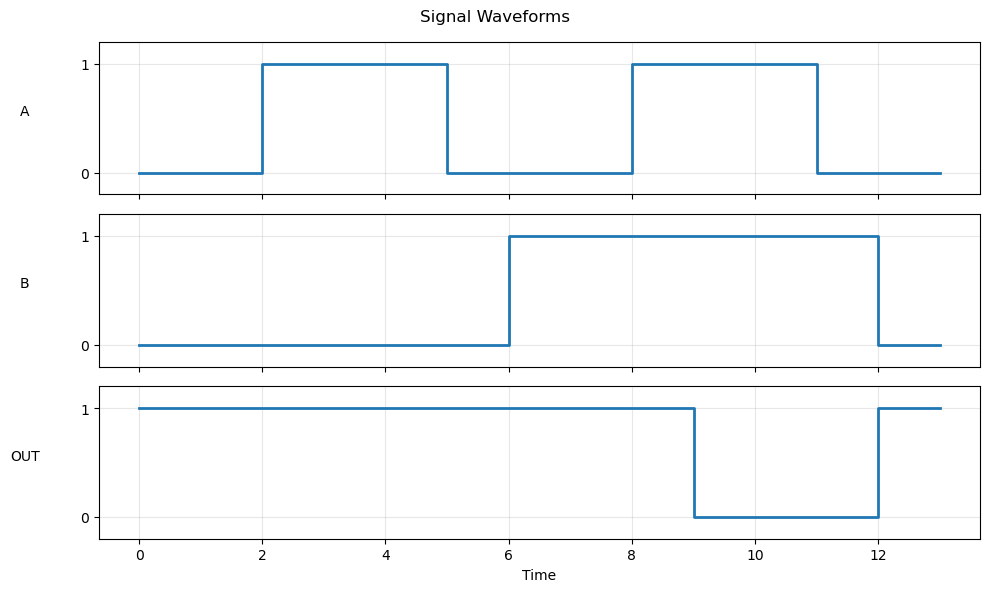

In [9]:
def plot_signals(nets):
    #Find the latest time across all nets to ensure signals are plotted for all time
    max_time = max(history[-1][0] for net in nets for history in [net.history] if history)
    #Sub plots for all nets
    fig, axes = plt.subplots(len(nets), 1, figsize=(10, 2 * len(nets)), sharex=True)

    #Plot every net
    for ax, net in zip(axes, nets):
        times, vals = zip(*net.history)
        #Extend to max time so all lines reach the end
        times = list(times) + [max_time + 1]
        vals  = list(vals)  + [vals[-1]]
        ax.step(times, vals, where='post', linewidth=2)
        ax.set_ylabel(net.name, rotation=0, labelpad=40)
        ax.set_ylim(-0.2, 1.2)
        ax.set_yticks([0, 1])
        ax.grid(True, alpha=0.3)

    #Label/title
    axes[-1].set_xlabel("Time")
    plt.suptitle("Signal Waveforms")
    plt.tight_layout()
    plt.show()

#Plot
plot_signals([A, B, OUT])

These visuals show the entire waveforms for all nets and further shows the expected behavior working correctly with a delay of 1. OUT is 0 except for when A and B are both 1

### Combinatorial NAND Gates

In [10]:
queue = []

#All wires
#Four inputs
A  = Net('A')
B  = Net('B')
C  = Net('C')
D  = Net('D')
#Intermediate outputs
W1 = Net('W1')
W2 = Net('W2')
#Final output
OUT  = Net('OUT')

#initialize
A.update(0,0)
B.update(0,0)
D.update(0,0)
C.update(0,0)
#Should be 1, rest are 0
W1.update(1, 0)
W2.update(1, 0)
OUT.update(0,0)

#Gates
#A and B in, W1 out
G1 = Gate('NAND', A, B, W1)
#C and D in, W2 out
G2 = Gate('NAND', C, D, W2)
#W1 and W2 in, OUT as final output
G3 = Gate('NAND', W1, W2, OUT)

#Input events
#A and B to 1
post_event(2, A, 1)
post_event(2, B, 1)
#C and D to 1
post_event(4, C, 1)
post_event(4, D, 1)
#A to 0
post_event(6, A, 0)      
#A to 1, B to 0
post_event(8, A, 1)
post_event(8, B, 0)
#B to 1
post_event(10, B, 1)
#C to 0
post_event(12, C, 0)
#A and B to 0
post_event(14, A, 0)
post_event(14, B, 0)

#Run simulation
run_simulation()

#Print net histories
for net in [A, B, C, D, W1, W2, OUT]:
    print(f"\n{net.name} history:")
    for time, val in net.history:
        print(f"  t={time}: {val}")


t=2: A -> 1
t=2: B -> 1
t=3: W1 -> 0
t=4: C -> 1
t=4: D -> 1
t=4: OUT -> 1
t=5: W2 -> 0
t=6: A -> 0
t=7: W1 -> 1
t=8: B -> 0
t=8: A -> 1
t=10: B -> 1
t=11: W1 -> 0
t=12: C -> 0
t=13: W2 -> 1
t=14: A -> 0
t=14: B -> 0
t=15: W1 -> 1
t=16: OUT -> 0

A history:
  t=0: 0
  t=2: 1
  t=6: 0
  t=8: 1
  t=14: 0

B history:
  t=0: 0
  t=2: 1
  t=8: 0
  t=10: 1
  t=14: 0

C history:
  t=0: 0
  t=4: 1
  t=12: 0

D history:
  t=0: 0
  t=4: 1

W1 history:
  t=0: 1
  t=3: 0
  t=7: 1
  t=11: 0
  t=15: 1

W2 history:
  t=0: 1
  t=5: 0
  t=13: 1

OUT history:
  t=0: 0
  t=4: 1
  t=16: 0


Our output signal starts at 1 here when all signals are 0. This is because this produces two 1s, which then produces a 0. After A and B are switched to be both 1s, we see that the final NAND gate would be taking a 0 and a 1 now, so OUT flips to be 1. C and D are switched to bot 1s as well and we can see W2 change accordingly, although OUT remains the same. All combinations are tested and OUT remains at 1. At t=14, both A and B are switched to 0 and W1 and W2 become 1. 2 seconds later, as expected, our output becomes 0 again. This validates all possible behavior and the delay is as expected. W1 and W2 update one unit after we change the inputs while the final output takes two seconds.

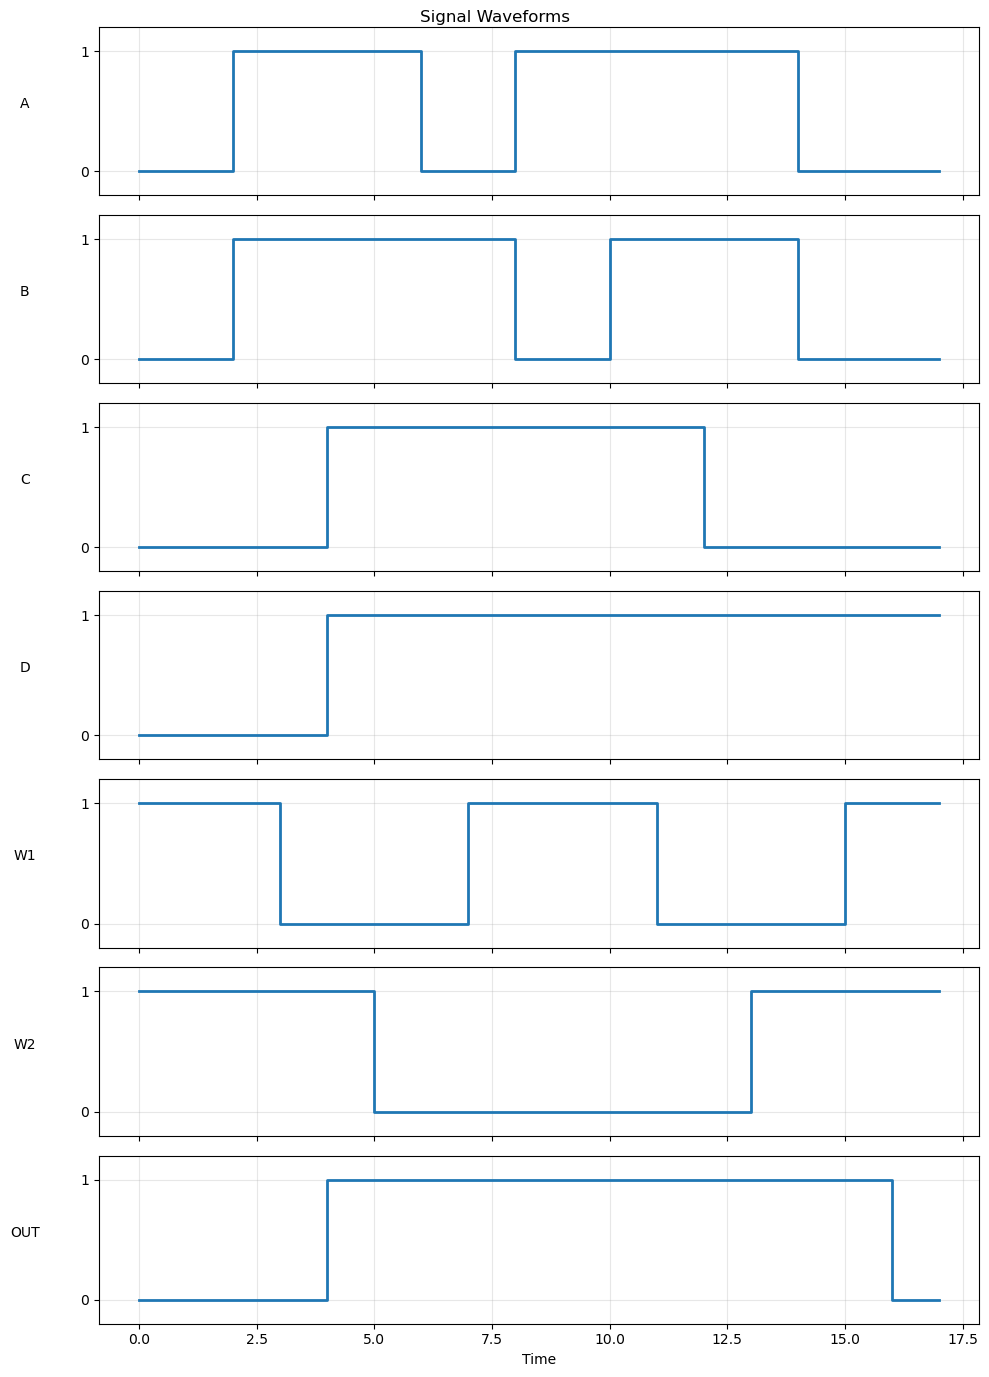

In [11]:
plot_signals([A, B, C, D, W1, W2, OUT])

All waveforms behave as expected and are consistent with print statements from before. 

## Part 2: NOR Gate Network

First, a single NOR gate will simulated for all input combinations to ensure it produces the desired outputs

In [12]:
#To hold all events
queue = []

#Create a NAND gate
#Inputs
A = Net('A')
B = Net('B')
#Output
OUT = Net('OUT')

#Initialize
A.update(0,0)
B.update(0,0)
OUT.update(1,0)

#Create gate
gate_1 = Gate('NOR', A, B, OUT)

#Add events to the queue, A and B are 0 to start
post_event(0, A, 0)
post_event(0, B, 0)
#1,0
post_event(2, A, 1)
post_event(2, B, 0)
#0,1
post_event(4, A, 0)
post_event(4, B, 1)
#1,1
post_event(6, A, 1)
post_event(6, B, 1)
#0,0
post_event(8, A, 0)
post_event(8, B, 0)

#Simulate
run_simulation()

#Print out updated values
for net in [A, B, OUT]:
    print(f"\n{net.name} history:")
    for time, val in net.history:
        print(f"  t={time}: {val}")


t=2: A -> 1
t=3: OUT -> 0
t=4: B -> 1
t=4: A -> 0
t=6: A -> 1
t=8: A -> 0
t=8: B -> 0
t=9: OUT -> 1

A history:
  t=0: 0
  t=2: 1
  t=4: 0
  t=6: 1
  t=8: 0

B history:
  t=0: 0
  t=4: 1
  t=8: 0

OUT history:
  t=0: 1
  t=3: 0
  t=9: 1


The NOR gate was validated for all possible values of A and B. At 0,0, we can see OUT goes to 1 as expected. Then, for all other combinations of 1,0, 0,1, and 1,1, we can see that OUT goes to 0. The gate has the expected delay and goes back up to 1 at the end when 0,0 is used again. This verifies the full behavior of the gate

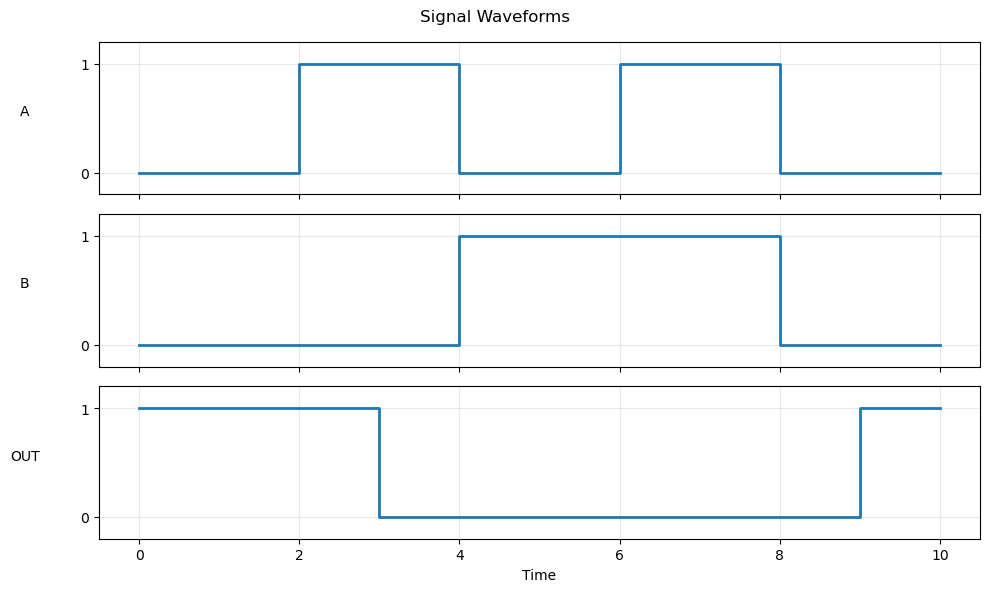

In [13]:
plot_signals([A, B, OUT])

The graphs can be used for further validation

Now, 3 NOR gates will be utilized for further validation

In [14]:
#CLear the queue
queue = []

#All wires
#Four inputs
A  = Net('A')
B  = Net('B')
C  = Net('C')
D  = Net('D')
#Intermediate outputs
W1 = Net('W1')
W2 = Net('W2')
#Final output
OUT  = Net('OUT')

#Should be 1, rest are 0
W1.update(1, 0)
W2.update(1, 0)
OUT.update(0,0)
A.update(0,0)
B.update(0,0)
C.update(0,0)
D.update(0,0)

#Gates
#A and B in, W1 out
G1 = Gate('NOR', A, B, W1)
#C and D in, W2 out
G2 = Gate('NOR', C, D, W2)
#W1 and W2 in, OUT as final output
G3 = Gate('NOR', W1, W2, OUT)

#Input events
#A and B to 1
post_event(2, A, 1)
post_event(2, B, 1)
#C and D to 1
post_event(4, C, 1)
post_event(4, D, 1)
#A to 0
post_event(6, A, 0)      
#A to 1, B to 0
post_event(8, A, 1)
post_event(9, B, 0)
#B to 1
post_event(11, B, 1)
#C to 0
post_event(13, C, 0)
#A and B to 0
post_event(15, A, 0)
post_event(16, B, 0)

#Run simulation
run_simulation()

#Print net histories
for net in [A, B, C, D, W1, W2, OUT]:
    print(f"\n{net.name} history:")
    for time, val in net.history:
        print(f"  t={time}: {val}")

t=2: A -> 1
t=2: B -> 1
t=3: W1 -> 0
t=4: C -> 1
t=4: D -> 1
t=5: W2 -> 0
t=6: A -> 0
t=6: OUT -> 1
t=8: A -> 1
t=9: B -> 0
t=11: B -> 1
t=13: C -> 0
t=15: A -> 0
t=16: B -> 0
t=17: W1 -> 1
t=18: OUT -> 0

A history:
  t=0: 0
  t=2: 1
  t=6: 0
  t=8: 1
  t=15: 0

B history:
  t=0: 0
  t=2: 1
  t=9: 0
  t=11: 1
  t=16: 0

C history:
  t=0: 0
  t=4: 1
  t=13: 0

D history:
  t=0: 0
  t=4: 1

W1 history:
  t=0: 1
  t=3: 0
  t=17: 1

W2 history:
  t=0: 1
  t=5: 0

OUT history:
  t=0: 0
  t=6: 1
  t=18: 0


For three nor gates, 0s for the inputs are initialized which creates W1 and W2 of 1, leading to an output of 0. Only when we are able to turn W1 and W2 into both 0s by flipping the input bits to 1 do we see the output go to 1. The other combinations are tested, and behave as expected, including the proper delay.

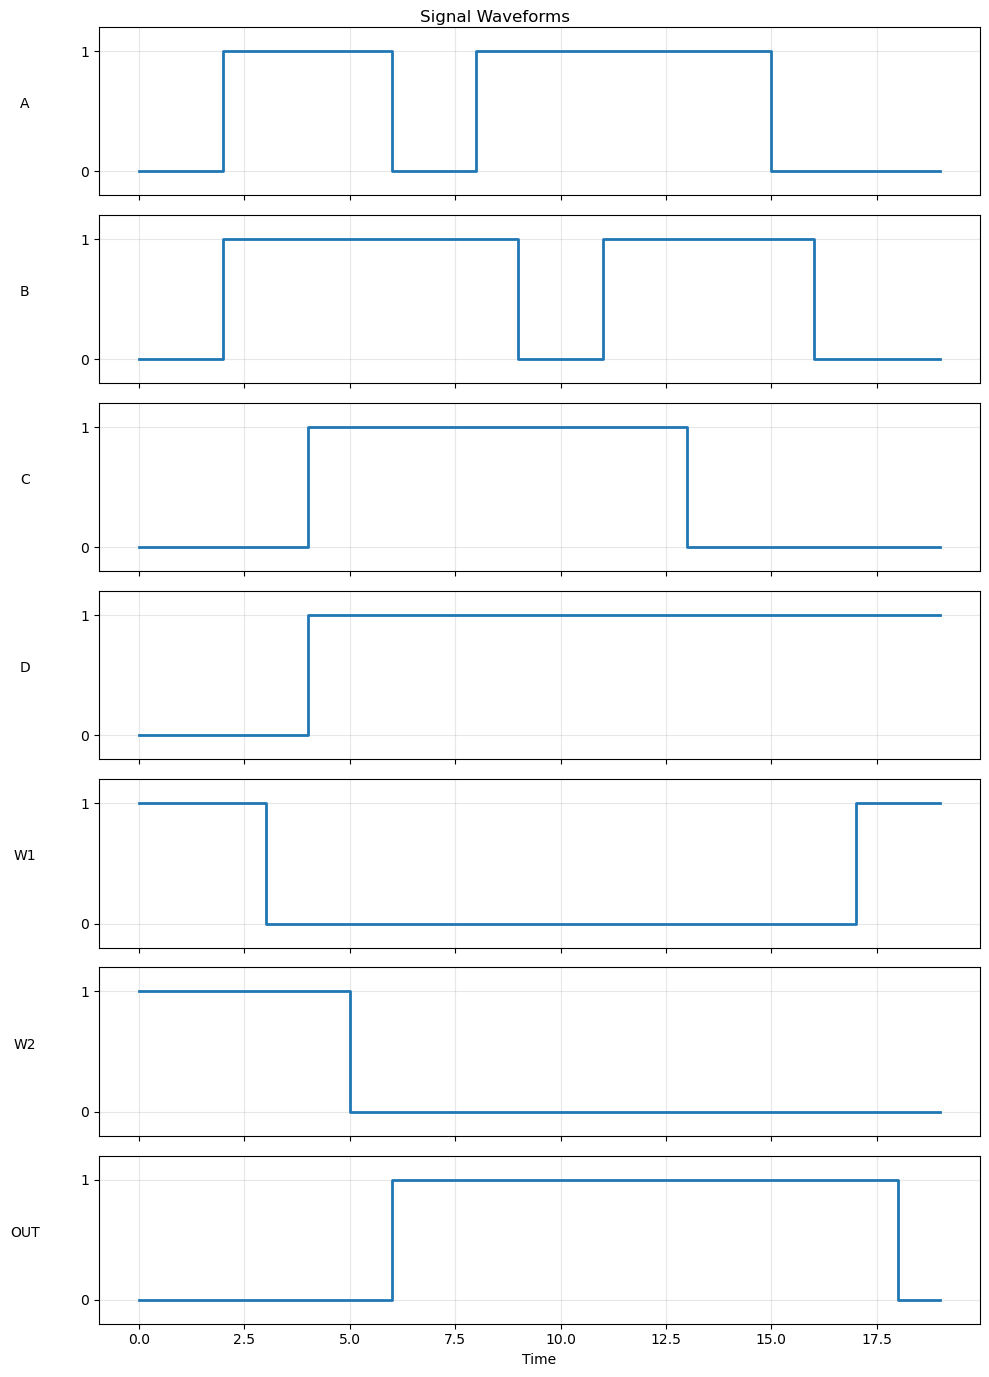

In [15]:
plot_signals([A, B, C, D, W1, W2, OUT])

## Part 3: NAND D-Latch

In [16]:
queue = []
#Nets
#Inputs
D = Net('D')
#Enable
E = Net('E')
#Inverted input
D_bar = Net('D_bar')
#First gate outputs
S = Net('S')
R = Net('R')
#Output and inverted output
Q = Net('Q')
Q_bar = Net('Q_bar')

#Input and enable 0
D.update(0, 0)
E.update(0, 0)
#D_bar is NOT D, starts as 1
D_bar.update(1, 0)
#Both first gates start as 1
S.update(1, 0)
R.update(1, 0)
#Reset state
Q.update(0, 0)
Q_bar.update(1, 0)

#Inverter
#Ensures D not gate updates, nor of itself is a not
G_INV = Gate('NOR', D, D, D_bar)
#Other gates
#First two
G1 = Gate('NAND', D, E, S)
G2 = Gate('NAND', D_bar, E, R)
#Last two
G3 = Gate('NAND', S, Q_bar, Q)
G4 = Gate('NAND', R, Q, Q_bar)

#Enable, input to 1
post_event(2, E, 1)
post_event(2, D, 1)

#Input to 0
post_event(6, D, 0)

#Disable
post_event(10, E, 0)

#Input change while enable is low
post_event(12, D, 1)
post_event(14, D, 0)

#Enable and set D to 1 again
post_event(16, E, 1)
post_event(18, D, 1)

#Run simulation
run_simulation()

#Print net histories
for net in [D, E, D_bar, S, R, Q, Q_bar]:
    print(f"\n{net.name} history:")
    for time, val in net.history:
        print(f"  t={time}: {val}")

t=2: E -> 1
t=2: D -> 1
t=3: R -> 0
t=3: D_bar -> 0
t=3: S -> 0
t=4: R -> 1
t=4: Q -> 1
t=5: Q_bar -> 0
t=6: D -> 0
t=7: D_bar -> 1
t=7: S -> 1
t=8: R -> 0
t=9: Q_bar -> 1
t=10: E -> 0
t=10: Q -> 0
t=11: R -> 1
t=12: D -> 1
t=13: D_bar -> 0
t=14: D -> 0
t=15: D_bar -> 1
t=16: E -> 1
t=17: R -> 0
t=18: D -> 1
t=19: D_bar -> 0
t=19: S -> 0
t=20: R -> 1
t=20: Q -> 1
t=21: Q_bar -> 0

D history:
  t=0: 0
  t=2: 1
  t=6: 0
  t=12: 1
  t=14: 0
  t=18: 1

E history:
  t=0: 0
  t=2: 1
  t=10: 0
  t=16: 1

D_bar history:
  t=0: 1
  t=3: 0
  t=7: 1
  t=13: 0
  t=15: 1
  t=19: 0

S history:
  t=0: 1
  t=3: 0
  t=7: 1
  t=19: 0

R history:
  t=0: 1
  t=3: 0
  t=4: 1
  t=8: 0
  t=11: 1
  t=17: 0
  t=20: 1

Q history:
  t=0: 0
  t=4: 1
  t=10: 0
  t=20: 1

Q_bar history:
  t=0: 1
  t=5: 0
  t=9: 1
  t=21: 0


The D-latch simulation shows correct behavior. When E is enabled the output Q follows D, toggling high when D is high and low when D is low. When E is disabled Q holds its last value even as D changes, demonstrating correct memory behavior. Q and Q_bar remain complements of each other at all times, and all output changes occur after the expected gate delay following input transitions. It is harder to verify the behavior with memory being used, but we are still able to ensure accuracy.

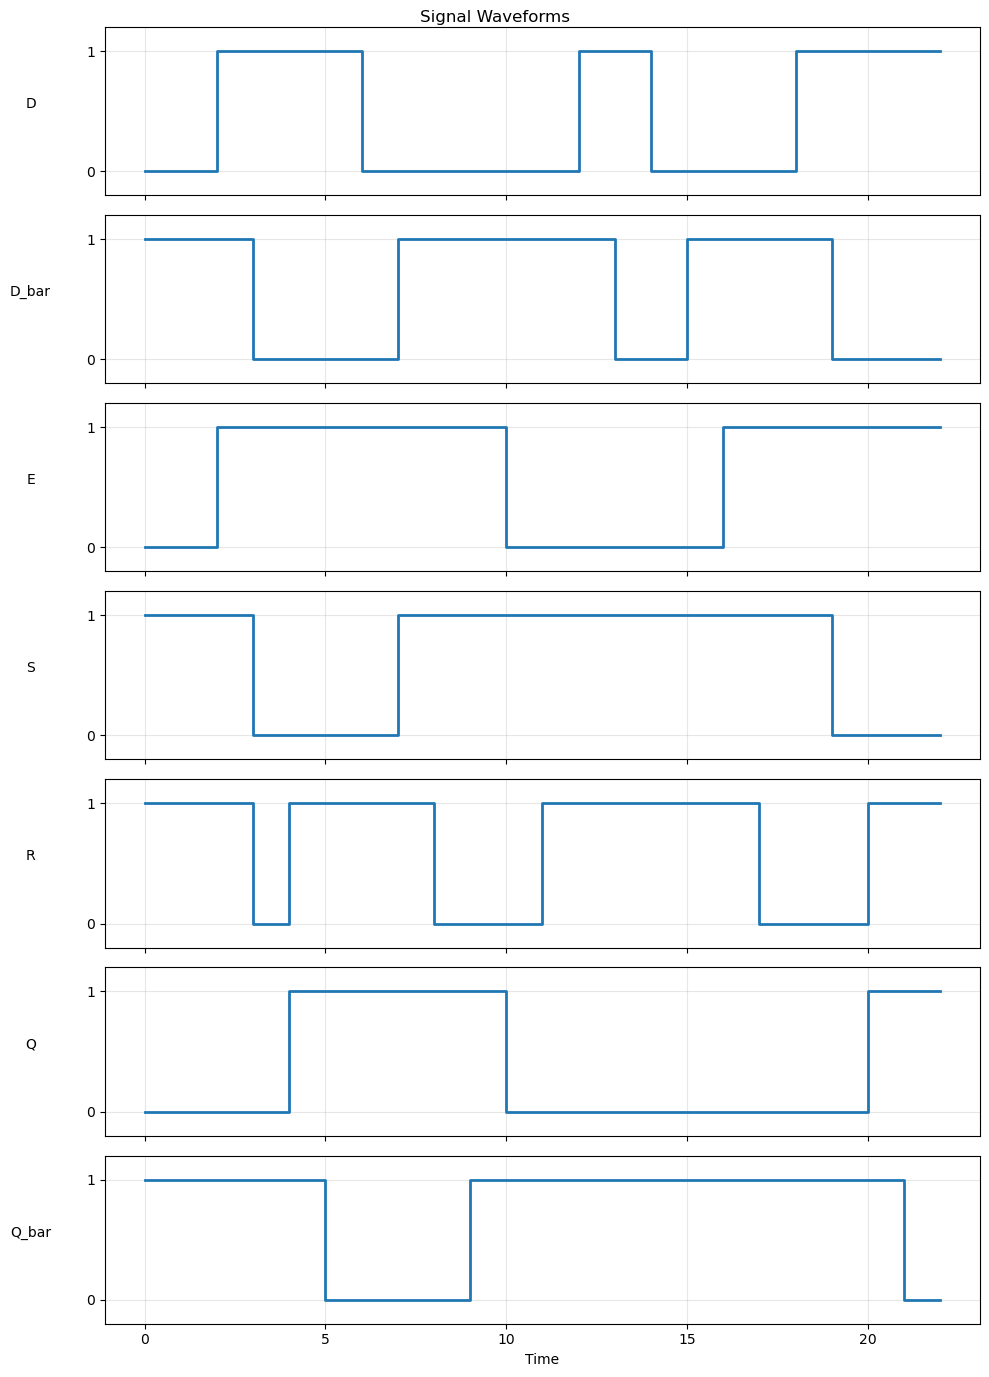

In [17]:
plot_signals([D, D_bar, E, S, R, Q, Q_bar])

## Part 4: Analysis of Combinatoral vs Sequential Networks

While the combinatorial and sequential networks shared many similarities in functionality and how they were simulated, there were some differences. First, initialization was required for the output gates in the D-latch as they are used in feedback where the combinatorial gates only required intiialization for the intermediate outputs. Because of this feedback loop, simulation for the D-latch was more complex. When Q updates, it propoagates back into itself, and can cause more changes after the original event has propagated. This means it is important to wait for the network to reach a stable state to observe its behavior. With the combinatorial, the same input values would always produce the same output. However in the D-latch, with memory, there can be different outputs.